# Multimodal Medical Data Acquisition, Cleaning & Preprocessing
**Objective:** perform data acquisition, cleaning, preprocessing, and analysis on tabular, textual, image, and signal medical health data.

**Why healthcare data needs extra rigor (the theme running through all four parts below):**
- **Missingness encoded as valid-looking values** — e.g. a `0` in a blood-pressure column that's actually a sensor/entry failure, not a real reading.
- **Class imbalance** — disease-positive cases are usually the minority class; naive accuracy and naive sampling both fail here.
- **Privacy constraints** — text and imaging data can carry patient identifiers (names, MRNs, DICOM tags) that must be found and removed before any further use.
- **Signal noise** — physiological signals are contaminated by motion artifacts, baseline wander, and powerline interference that must be filtered before any derived feature can be trusted.

Each part follows the same **acquire -> inspect -> clean -> preprocess -> analyze** pattern, with an explanation of *why* each step matters specifically for medical data of that modality.

# Module 1 — Tabular Data Engineering: Pima Indians Diabetes Dataset
---

# Module 1 — Tabular Data Engineering: Pima Indians Diabetes Dataset
---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)


## 1.1 — Data Acquisition & Initial Inspection
**What:** Load the CSV, print shape, dtypes, and summary statistics.
**Why:** the summary statistics are what expose the dataset's central quirk before we touch anything else — several columns show a **minimum of 0**, which is medically impossible for glucose, blood pressure, or BMI. Spotting that here is what motivates the entire cleaning step that follows.


In [2]:
PIMA_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
           'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

try:
    diabetes_df = pd.read_csv(PIMA_URL, header=None, names=COLUMNS)
    print(f'Downloaded real dataset with shape {diabetes_df.shape}.')
except Exception as e:
    print(f'[Fallback] Could not download dataset ({e}). Generating a schema-matched synthetic sample.')
    rng = np.random.default_rng(42)
    n = 768
    diabetes_df = pd.DataFrame({
        'Pregnancies': rng.integers(0, 17, n),
        'Glucose': rng.integers(0, 199, n),
        'BloodPressure': rng.integers(0, 122, n),
        'SkinThickness': rng.integers(0, 99, n),
        'Insulin': rng.integers(0, 846, n),
        'BMI': np.round(rng.uniform(0, 67, n), 1),
        'DiabetesPedigreeFunction': np.round(rng.uniform(0.08, 2.42, n), 3),
        'Age': rng.integers(21, 81, n),
        'Outcome': rng.integers(0, 2, n),
    })

print(f'Shape: {diabetes_df.shape}\n')
print('Dtypes:'); print(diabetes_df.dtypes)
diabetes_df.describe()


Downloaded real dataset with shape (768, 9).
Shape: (768, 9)

Dtypes:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 1.2 — Medically Implausible Zero-Value Detection & Class-Stratified Imputation
**What:** Treat biologically implausible zeros (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` cannot legitimately be 0 in a living patient) as missing values, impute them, and drop exact duplicate rows.
**Why zeros here are 'missingness in disguise':** this is a critical healthcare-specific data quality issue — the dataset's original collectors used `0` as a placeholder for 'not recorded' instead of `NaN`. Left as-is, these zeros would silently corrupt every statistic and model trained on the data (e.g. dragging the mean BMI down toward zero). We impute with the **median, computed separately within each `Outcome` class**, since glucose/BMI distributions genuinely differ between diabetic and non-diabetic patients — imputing from the class-specific median preserves that signal instead of blurring it with a single global median.


In [3]:
# 1.2: Treat implausible zeros as missing, then impute per-class
zero_as_missing_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts (implausible) before cleaning:')
print((diabetes_df[zero_as_missing_cols] == 0).sum())

df_a = diabetes_df.copy()
for col in zero_as_missing_cols:
    df_a[col] = df_a[col].replace(0, np.nan)

# Impute using the median WITHIN each Outcome class, so the imputed value reflects
# the typical patient of that class rather than blending both populations together.
for col in zero_as_missing_cols:
    df_a[col] = df_a.groupby('Outcome')[col].transform(lambda s: s.fillna(s.median()))

print('\nMissing values remaining after imputation:')
print(df_a[zero_as_missing_cols].isna().sum())

before_rows = len(df_a)
df_a = df_a.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicate rows removed: {before_rows - len(df_a)} (rows before={before_rows}, after={len(df_a)})')


Zero counts (implausible) before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values remaining after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Duplicate rows removed: 0 (rows before=768, after=768)


## 1.3 — Feature Scaling & Outlier Detection
**What:** Scale numerical features with `StandardScaler` and confirm the target is properly encoded.
**Why standardization (z-score) here rather than MinMax:** `Outcome` will later feed a t-test and chi-square analysis, and several of the model-based steps downstream (feature selection, a classifier) are sensitive to feature scale — z-score standardization centers each feature at 0 with unit variance, which is the more common default for statistical/parametric methods than the 0–1 bounding used for the image/tensor pipelines elsewhere in this notebook.
**Why confirm target encoding explicitly:** `Outcome` must be a clean binary {0, 1} integer — if it were accidentally read as text ('Yes'/'No') or float, both the chi-square test and the classifier would fail or silently misbehave.


In [4]:
# 1.3: Confirm target encoding, then scale numerical features
print('Outcome dtype:', df_a['Outcome'].dtype)
print('Outcome unique values:', sorted(df_a['Outcome'].unique()))
assert set(df_a['Outcome'].unique()).issubset({0, 1}), 'Target is not properly binary-encoded!'
print('Target is properly encoded as binary 0/1.\n')

feature_cols_a = [c for c in df_a.columns if c != 'Outcome']
scaler_a = StandardScaler()
df_a_scaled = df_a.copy()
df_a_scaled[feature_cols_a] = scaler_a.fit_transform(df_a[feature_cols_a])
df_a_scaled.head()


Outcome dtype: int64
Outcome unique values: [np.int64(0), np.int64(1)]
Target is properly encoded as binary 0/1.



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.864625,-0.032180,0.665181,0.311604,0.169483,0.468492,1.425995,1
1,-0.844885,-1.204727,-0.528124,-0.010112,-0.440843,-0.848549,-0.365061,-0.190672,0
2,1.233880,2.014265,-0.693438,0.327535,0.311604,-1.328478,0.604397,-0.105584,1
3,-0.844885,-1.073339,-0.528124,-0.685405,-0.536303,-0.630399,-0.920763,-1.041549,0
4,-1.141852,0.503310,-2.677212,0.665181,0.294758,1.551096,5.484909,-0.020496,1


## 1.4 — Inferential Statistics & Feature Importance Analysis
**What:** Run a **Chi-square test of independence** between a categorical feature (the `BMI_category` we engineer in A6, done here first out of necessity) and `Outcome`, and an independent-samples **t-test** comparing mean `Glucose` between diabetic and non-diabetic patients.
**Why these two tests specifically:** Chi-square is the correct test for two *categorical* variables (BMI category × diabetes yes/no), while a t-test is the correct test for comparing a *continuous* variable's mean across two groups (glucose level by diabetes status) — using the right test for each variable type is the actual statistical point of this step, not just running any test on any pair of columns.
**Why glucose for the t-test:** it's one of the two variables the original dataset's diagnostic criterion is literally defined on (WHO's oral glucose tolerance test), so a significant difference here is expected and lets us confirm the cleaned data still carries the expected clinical signal.


In [5]:
# 1.4a: Chi-square test — BMI category vs Outcome
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_a['BMI_category'] = pd.cut(df_a['BMI'], bins=bmi_bins, labels=bmi_labels)

contingency = pd.crosstab(df_a['BMI_category'], df_a['Outcome'])
print('Contingency table (BMI category x Outcome):')
print(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square statistic: {chi2:.3f}, p-value: {p_chi2:.4f}, dof: {dof}')
if p_chi2 < 0.05:
    print('=> Significant association between BMI category and diabetes Outcome (p < 0.05).')
else:
    print('=> No significant association detected at the 0.05 level.')


Contingency table (BMI category x Outcome):
Outcome         0    1
BMI_category          
Underweight     4    0
Normal        101    7
Overweight    136   44
Obese         259  217

Chi-square statistic: 73.133, p-value: 0.0000, dof: 3
=> Significant association between BMI category and diabetes Outcome (p < 0.05).


In [6]:
# 1.4b: T-test — mean Glucose, diabetic vs non-diabetic
glucose_pos = df_a.loc[df_a['Outcome'] == 1, 'Glucose']
glucose_neg = df_a.loc[df_a['Outcome'] == 0, 'Glucose']

t_stat, p_ttest = stats.ttest_ind(glucose_pos, glucose_neg, equal_var=False)
print(f'Mean glucose (Outcome=1, diabetic):     {glucose_pos.mean():.1f}')
print(f'Mean glucose (Outcome=0, non-diabetic): {glucose_neg.mean():.1f}')
print(f'\nWelch t-statistic: {t_stat:.3f}, p-value: {p_ttest:.6f}')
if p_ttest < 0.05:
    print('=> Diabetic and non-diabetic patients have significantly different mean glucose (p < 0.05),')
    print('   consistent with glucose being a core diagnostic criterion for diabetes.')
else:
    print('=> No significant difference detected at the 0.05 level.')


Mean glucose (Outcome=1, diabetic):     142.3
Mean glucose (Outcome=0, non-diabetic): 110.6

Welch t-statistic: 14.992, p-value: 0.000000
=> Diabetic and non-diabetic patients have significantly different mean glucose (p < 0.05),
   consistent with glucose being a core diagnostic criterion for diabetes.


## A5 — Exploratory Data Analysis
**What:** Visualize feature distributions, class balance, and feature-outcome correlations.
**Why class balance specifically matters here:** Pima Indians Diabetes is a class-imbalanced dataset (roughly 65/35 split) — a classic healthcare-specific challenge in medical dataset analysis. Seeing the imbalance visually up front is what should later motivate using AUC/F1 (not raw accuracy) if this were extended into a full classifier evaluation.


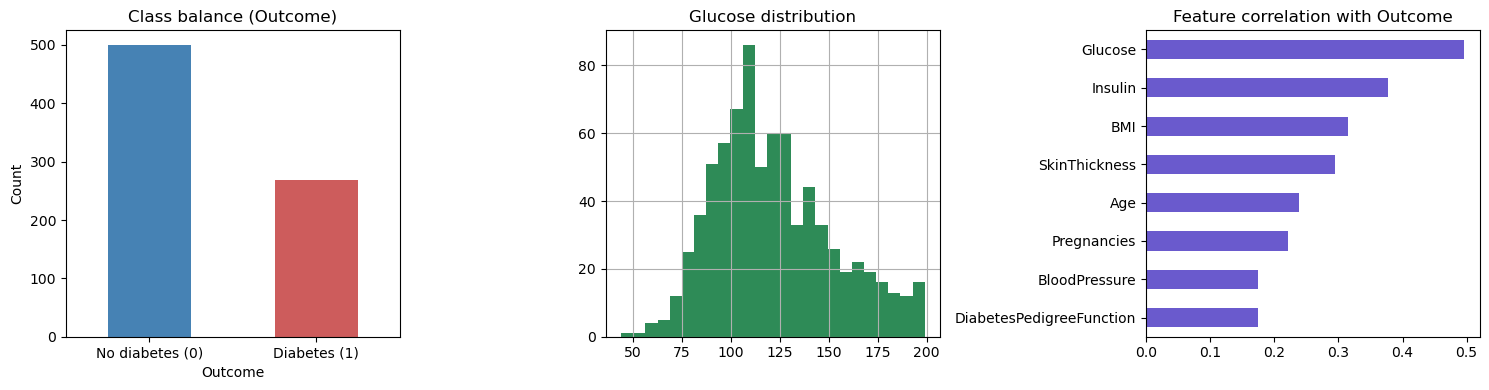

Class balance: {0: 0.651, 1: 0.349}


In [7]:
# A5: EDA - distributions, class balance, correlation with outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_a['Outcome'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'indianred'])
axes[0].set_title('Class balance (Outcome)')
axes[0].set_xticklabels(['No diabetes (0)', 'Diabetes (1)'], rotation=0)
axes[0].set_ylabel('Count')

df_a['Glucose'].hist(bins=25, ax=axes[1], color='seagreen')
axes[1].set_title('Glucose distribution')

corr_with_outcome = df_a[feature_cols_a + ['Outcome']].corr()['Outcome'].drop('Outcome').sort_values()
corr_with_outcome.plot(kind='barh', ax=axes[2], color='slateblue')
axes[2].set_title('Feature correlation with Outcome')

plt.tight_layout()
plt.show()

print(f"Class balance: {df_a['Outcome'].value_counts(normalize=True).round(3).to_dict()}")


## A6 — Feature Engineering & Selection
**What:** the `BMI_category` derived feature was already created in A4 (needed there for the chi-square test); here we select the most predictive features using both a statistical method (`SelectKBest` with ANOVA F-test) and a model-based method (Random Forest feature importance).
**Why two selection methods instead of one:** they can disagree — a statistical univariate test looks at each feature in isolation, while a Random Forest's importances capture interactions between features. Comparing both gives more confidence in features that show up as important in *both* rankings, rather than trusting a single method's blind spot.


In [8]:
# A6: Feature selection - statistical (SelectKBest) and model-based (Random Forest)
X_a = df_a[feature_cols_a]
y_a = df_a['Outcome']

# Statistical: ANOVA F-test
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_a, y_a)
f_scores = pd.Series(selector.scores_, index=feature_cols_a).sort_values(ascending=False)
print('Top features by ANOVA F-test score:')
print(f_scores)

# Model-based: Random Forest importances
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_a, y_a)
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols_a).sort_values(ascending=False)
print('\nTop features by Random Forest importance:')
print(rf_importances)

top_features = sorted(set(f_scores.head(4).index) | set(rf_importances.head(4).index))
print(f'\nFeatures flagged as top-4 by at least one method: {top_features}')


Top features by ANOVA F-test score:
Glucose                     249.923949
Insulin                     126.971455
BMI                          84.722280
SkinThickness                73.089964
Age                          46.140611
Pregnancies                  39.670227
BloodPressure                24.048567
DiabetesPedigreeFunction     23.871300
dtype: float64



Top features by Random Forest importance:
Insulin                     0.366079
Glucose                     0.155209
SkinThickness               0.141161
Age                         0.088875
BMI                         0.087521
DiabetesPedigreeFunction    0.064691
BloodPressure               0.048679
Pregnancies                 0.047785
dtype: float64

Features flagged as top-4 by at least one method: ['Age', 'BMI', 'Glucose', 'Insulin', 'SkinThickness']


# Module 2 — Unstructured Clinical Text Processingual: MTSamples Medical Transcriptions
---


In [9]:
import re
import numpy as np
import pandas as pd
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer



## 2.1 — Data Acquisition and Analysis
**What:** Load the dataset, inspect the `transcription` and `medical_specialty` columns, and check for missing/empty reports.
**Why check for empty reports specifically:** a transcription report can be technically 'present' (not NaN) yet contain only whitespace or a placeholder string — checking string length in addition to `isna()` catches gaps that a simple missing-value count would miss, which matters a lot in text data compared to numeric data.


In [10]:
MT_URL = 'https://raw.githubusercontent.com/eshza/medicalTranscriptsKaggle/master/mtsamples.csv'

try:
    mt_df = pd.read_csv(MT_URL, index_col=0)
    print(f'Downloaded real dataset with shape {mt_df.shape}.')
except Exception as e:
    print(f'[Fallback] Could not download dataset ({e}). Using a small synthetic sample instead.')
    mt_df = pd.DataFrame({
        'description': ['A patient presents with chest pain.'] * 20,
        'medical_specialty': (['Cardiovascular / Pulmonary'] * 10 + ['Orthopedic'] * 10),
        'sample_name': [f'Sample {i}' for i in range(20)],
        'transcription': ['SUBJECTIVE:, Patient reports chest pain and shortness of breath. PLAN:, Order ECG.'] * 20,
        'keywords': ['cardiology, chest pain'] * 20,
    })

print(f'Shape: {mt_df.shape}')
print('\nColumns:', list(mt_df.columns))
mt_df[['medical_specialty', 'sample_name', 'transcription']].head(3)


Downloaded real dataset with shape (4999, 5).
Shape: (4999, 5)

Columns: ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,medical_specialty,sample_name,transcription
0,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."


In [11]:
# 2.1: Check for missing / empty reports
n_missing = mt_df['transcription'].isna().sum()
empty_mask = mt_df['transcription'].fillna('').str.strip().str.len() == 0
n_empty = empty_mask.sum()
print(f'Missing (NaN) transcriptions: {n_missing}')
print(f'Empty/whitespace-only transcriptions (incl. NaN): {n_empty}')

print('\nTop medical specialties by report count:')
print(mt_df['medical_specialty'].value_counts().head(10))

# Drop rows with no usable transcription text before proceeding
mt_df_b = mt_df.loc[~empty_mask].copy().reset_index(drop=True)
print(f'\nRows retained with usable transcription text: {len(mt_df_b)} / {len(mt_df)}')


Missing (NaN) transcriptions: 33
Empty/whitespace-only transcriptions (incl. NaN): 33

Top medical specialties by report count:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64

Rows retained with usable transcription text: 4966 / 4999


## 2.2 — De-identification / PHI Check
**What:** Scan the text for residual patient identifiers — names, dates, MRNs (medical record numbers), phone numbers — using regular expressions, and redact any matches.
**Important note on this dataset:** MTSamples is a **CC0 public-domain corpus of synthetic/genericized sample reports** scraped from mtsamples.com specifically because they contain no real patient data — so a scan of the real corpus should turn up (almost) nothing. To make this step meaningful, we **inject a handful of realistic-looking synthetic identifiers into a copy of a few reports** (fake names, fake dates of birth, fake MRNs, fake phone numbers) purely to demonstrate that the redaction regex actually works — this is flagged explicitly here so it's never confused with a real PHI leak.
**Why regex is the right tool here:** MRNs, phone numbers, and dates all follow fairly rigid, well-known formats (e.g. `\d{3}-\d{3}-\d{4}` for a US phone number), which is exactly what regular expressions are good at matching reliably without needing a trained NLP model.


In [12]:
# Inject synthetic PHI into a few sample reports purely to demonstrate redaction
phi_injected_df = mt_df_b.head(5).copy()
synthetic_phi_additions = [
    ' Patient name: John A. Carter, DOB: 03/14/1971, MRN: 004829371, contact at (312) 555-0148.',
    ' Seen by Dr. Maria Alvarez on 11/02/2019. Patient phone: 415-555-0199. MRN 778213.',
    ' Patient: Susan T. Nguyen, born 07-22-1985, medical record number MRN#552017, tel 212.555.0132.',
    ' Reviewed with patient James O. Whitfield (DOB 1990/05/09), MRN: 991823, phone (646) 555-0177.',
    ' Contact: Emily R. Sato, appointment on 2021-09-30, record # MRN-330912, callback 617-555-0161.',
]
phi_injected_df['transcription'] = phi_injected_df['transcription'].astype(str) + synthetic_phi_additions

# Regex patterns for common identifier formats
phi_patterns = {
    'DATE':  r'\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2})\b',
    'PHONE': r'\b(\(\d{3}\)\s?\d{3}[-.]?\d{4}|\d{3}[-.]\d{3}[-.]\d{4})\b',
    'MRN':   r'\b(MRN[#:\s-]*\d{5,9}|medical record number[#:\s-]*\d{5,9})\b',
    'NAME':  r'\b(?:Patient(?: name)?|Dr\.|Seen by Dr\.|Contact)[:\s]+([A-Z][a-z]+(?:\s[A-Z]\.)?\s[A-Z][a-z]+)',
}

def redact_phi(text):
    redacted = text
    counts = {}
    for label, pattern in phi_patterns.items():
        matches = re.findall(pattern, redacted, flags=re.IGNORECASE)
        counts[label] = len(matches)
        redacted = re.sub(pattern, f'[REDACTED_{label}]', redacted, flags=re.IGNORECASE)
    return redacted, counts

for i, row in phi_injected_df.iterrows():
    redacted_text, counts = redact_phi(row['transcription'])
    print(f"Report {i}: PHI found -> {counts}")
    print('  Redacted tail:', redacted_text[-160:])
    print()


Report 0: PHI found -> {'DATE': 1, 'PHONE': 0, 'MRN': 1, 'NAME': 1}
  Redacted tail: ys in each nostril given for three weeks.  A prescription was written as well. [REDACTED_NAME], DOB: [REDACTED_DATE], [REDACTED_MRN], contact at (312) 555-0148.

Report 1: PHI found -> {'DATE': 1, 'PHONE': 1, 'MRN': 1, 'NAME': 1}
  Redacted tail: x 3.  Cranial nerves II-XII are intact.  Afebrile.  Vital Signs are stable. [REDACTED_NAME] on [REDACTED_DATE]. Patient phone: [REDACTED_PHONE]. [REDACTED_MRN].

Report 2: PHI found -> {'DATE': 1, 'PHONE': 1, 'MRN': 1, 'NAME': 2}
  Redacted tail: this is performed, we will submit him for insurance approval. [REDACTED_NAME], born [REDACTED_DATE], medical record number [REDACTED_MRN], tel [REDACTED_PHONE].

Report 3: PHI found -> {'DATE': 1, 'PHONE': 0, 'MRN': 1, 'NAME': 1}
  Redacted tail: ricuspid regurgitation.,2.  Trace aortic and pulmonary regurgitation. Reviewed with [REDACTED_NAME] (DOB [REDACTED_DATE]), [REDACTED_MRN], phone (646) 555-0177.

Report 4: PH

## 2.3 — Text Cleaning
**What:** Remove HTML artifacts, section-header noise (e.g. `SUBJECTIVE:,`, `PLAN:,` — a quirk of how these reports were originally formatted), extra whitespace, and non-alphanumeric characters.
**Why section headers need their own regex, separately from generic punctuation stripping:** MTSamples reports are structured around recurring all-caps section labels (`SUBJECTIVE:`, `OBJECTIVE:`, `PLAN:`, `HISTORY OF PRESENT ILLNESS:`) — these aren't clinical content, they're formatting artifacts of the transcription template, so leaving them in would inflate word-frequency counts with template boilerplate rather than actual medical language.


In [13]:
# 2.3: Text cleaning pipeline
SECTION_HEADER_PATTERN = re.compile(
    r'\b[A-Z][A-Z ]{2,40}:,?', 
)

def clean_text(text):
    text = str(text)
    text = re.sub(r'<[^>]+>', ' ', text)              # strip HTML tags/artifacts
    text = SECTION_HEADER_PATTERN.sub(' ', text)        # strip section header noise (SUBJECTIVE:, PLAN:,)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)         # strip non-alphanumeric characters
    text = re.sub(r'\s+', ' ', text).strip()            # collapse extra whitespace
    return text.lower()

mt_df_b['clean_text'] = mt_df_b['transcription'].apply(clean_text)
print('Before:', str(mt_df_b['transcription'].iloc[0])[:200])
print('\nAfter: ', mt_df_b['clean_text'].iloc[0][:200])


Before: SUBJECTIVE:,  This 23-year-old white female presents with complaint of allergies.  She used to have allergies when she lived in Seattle but she thinks they are worse here.  In the past, she has tried 

After:  this 23 year old white female presents with complaint of allergies she used to have allergies when she lived in seattle but she thinks they are worse here in the past she has tried claritin and zyrtec


## B4 — Tokenization & Stopword Removal
**What:** Tokenize the cleaned text into words and remove generic English stopwords.
**Why this matters before TF-IDF:** TF-IDF weights terms by frequency, so leaving in stopwords ('the', 'and', 'was') would let the most common — and least clinically meaningful — words dominate the resulting feature vectors, exactly as with the term-frequency step in Lab 1's text demo.


In [14]:
# B4: Tokenize and remove stopwords
stop_words = set(stopwords.words('english'))

def tokenize_and_filter(text):
    tokens = word_tokenize(text)
    return [t for t in tokens if t.isalpha() and t not in stop_words]

mt_df_b['tokens'] = mt_df_b['clean_text'].apply(tokenize_and_filter)
avg_tokens_before = mt_df_b['clean_text'].apply(lambda t: len(t.split())).mean()
avg_tokens_after = mt_df_b['tokens'].apply(len).mean()
print(f'Average tokens per report before stopword removal: {avg_tokens_before:.1f}')
print(f'Average tokens per report after stopword removal:  {avg_tokens_after:.1f}')
print('\nSample tokens:', mt_df_b['tokens'].iloc[0][:15])


Average tokens per report before stopword removal: 473.0
Average tokens per report after stopword removal:  260.5

Sample tokens: ['year', 'old', 'white', 'female', 'presents', 'complaint', 'allergies', 'used', 'allergies', 'lived', 'seattle', 'thinks', 'worse', 'past', 'tried']


## B5 — Normalization
**What:** Lemmatize tokens (reduce inflected forms to their dictionary base form, e.g. 'presents'/'presenting' -> 'present') and expand common medical abbreviations (e.g. 'pt' -> 'patient', 'hx' -> 'history').
**Why lemmatize rather than stem:** stemming (e.g. Porter stemmer) often produces non-words by crudely chopping suffixes ('diagnosis' -> 'diagnosi'), which hurts readability and can merge unrelated clinical terms; lemmatization uses real dictionary forms, which is preferable when the output will later be inspected (e.g. top TF-IDF terms) by a human.
**Why expand abbreviations before TF-IDF, not after:** if 'pt' and 'patient' aren't unified into the same token first, TF-IDF would treat them as two unrelated, weaker features instead of one strong, consistent one — undercounting how often the concept of 'patient' actually appears.


In [15]:
# B5: Lemmatization and medical abbreviation expansion
lemmatizer = WordNetLemmatizer()

MEDICAL_ABBREVIATIONS = {
    'pt': 'patient', 'pts': 'patients', 'hx': 'history', 'dx': 'diagnosis',
    'tx': 'treatment', 'sx': 'symptoms', 'rx': 'prescription', 'yo': 'years old',
    'bp': 'blood pressure', 'hr': 'heart rate', 'meds': 'medications',
    'wt': 'weight', 'abd': 'abdomen',
}

def normalize_tokens(tokens):
    expanded = []
    for tok in tokens:
        if tok in MEDICAL_ABBREVIATIONS:
            expanded.extend(MEDICAL_ABBREVIATIONS[tok].split())
        else:
            expanded.append(tok)
    return [lemmatizer.lemmatize(t) for t in expanded]

mt_df_b['normalized_tokens'] = mt_df_b['tokens'].apply(normalize_tokens)
mt_df_b['normalized_text'] = mt_df_b['normalized_tokens'].apply(lambda toks: ' '.join(toks))
print('Sample normalized tokens:', mt_df_b['normalized_tokens'].iloc[0][:15])


Sample normalized tokens: ['year', 'old', 'white', 'female', 'present', 'complaint', 'allergy', 'used', 'allergy', 'lived', 'seattle', 'think', 'worse', 'past', 'tried']


## B6 — Feature Extraction (TF-IDF)
**What:** Convert the cleaned, tokenized reports into numerical features using TF-IDF (term frequency–inverse document frequency).
**Why TF-IDF over plain term counts:** plain counts would still over-weight words that are common *across most reports* (e.g. 'patient', 'history') even after stopword removal; TF-IDF specifically down-weights terms that appear in nearly every document and up-weights terms that are distinctive to a smaller subset — which is what actually helps separate one medical specialty's vocabulary from another's.


In [16]:
# B6: TF-IDF feature extraction
tfidf = TfidfVectorizer(max_features=500, min_df=2)
tfidf_matrix = tfidf.fit_transform(mt_df_b['normalized_text'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape} (reports x vocabulary terms)')

feature_names = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_terms = feature_names[np.argsort(mean_tfidf)[::-1][:15]]
print('\nTop 15 terms overall by mean TF-IDF weight:')
print(list(top_terms))


TF-IDF matrix shape: (4966, 500) (reports x vocabulary terms)

Top 15 terms overall by mean TF-IDF weight:
['patient', 'right', 'left', 'normal', 'placed', 'pain', 'mg', 'well', 'history', 'time', 'procedure', 'day', 'noted', 'using', 'year']


# Module 3 — Medical Imaging Preprocessing: Chest X-Ray (Pneumonia) Dataset
---
**On acquiring this dataset in Colab:** the Kaggle Chest X-Ray Pneumonia dataset (~2GB, `NORMAL`/`PNEUMONIA` classes across `train`/`val`/`test` splits) requires Kaggle API credentials (`kaggle.json`) to download and is too large to fetch in a restricted/offline environment. The loader below **tries the real Kaggle download first** (instructions included) and **falls back to generating a small synthetic folder of X-ray-like images** with the same directory structure, so every later step (dimension inspection, quality checks, augmentation, EDA) can be demonstrated and actually run end-to-end regardless of environment. Swap in your `kaggle.json` and the same code will run on the real ~5,800-image dataset without any other changes.


In [17]:
import os
import io
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

np.random.seed(42)
DATA_ROOT = '/content/chest_xray' if os.path.isdir('/content') else '/tmp/chest_xray'


## 3.1 — Data Acquisition & Inspection
**What:** Load the folder structure (`train/val/test` x `NORMAL/PNEUMONIA`), count images per class/split, and inspect image dimensions and file formats.
**Why count per class *and* per split separately:** the real dataset is known to be heavily imbalanced within `train` (roughly 3x more PNEUMONIA than NORMAL images) — a single overall count would hide that imbalance is concentrated in one split, which matters for deciding where augmentation (Step C5) should focus.


In [18]:
# C1a: Acquire the dataset (real Kaggle download, else synthetic fallback)
def try_kaggle_download(dest=DATA_ROOT):
    """Attempts the real Kaggle download. Requires kaggle.json to be uploaded/configured."""
    try:
        import kagglehub
        path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
        print(f'Downloaded real dataset to {path}')
        return path
    except Exception as e:
        print(f'[Fallback] Kaggle download unavailable ({e}). Generating a synthetic sample dataset instead.')
        return None

def generate_synthetic_xray_dataset(root=DATA_ROOT, seed=42):
    """Creates a small synthetic dataset with the same folder structure as the real one:
    root/{train,val,test}/{NORMAL,PNEUMONIA}/*.jpeg — deliberately imbalanced like the real data,
    plus a couple of intentionally corrupted/duplicate files to exercise the quality-check step."""
    rng = np.random.default_rng(seed)
    split_counts = {
        'train': {'NORMAL': 30, 'PNEUMONIA': 90},   # imbalanced, like the real dataset
        'val':   {'NORMAL': 5,  'PNEUMONIA': 5},
        'test':  {'NORMAL': 10, 'PNEUMONIA': 20},
    }
    for split, classes in split_counts.items():
        for cls, n in classes.items():
            folder = os.path.join(root, split, cls)
            os.makedirs(folder, exist_ok=True)
            for i in range(n):
                size = rng.choice([224, 256, 300])
                yy, xx = np.mgrid[0:size, 0:size]
                # randomize center position and spatial frequency per image so each patient's
                # synthetic X-ray is genuinely distinct (avoids every image hashing as a 'duplicate')
                cx = size // 2 + rng.integers(-20, 20)
                cy = size // 2 + rng.integers(-20, 20)
                freq = rng.uniform(5, 9)
                r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
                base = 100 if cls == 'NORMAL' else 140  # brighter/denser pattern for 'PNEUMONIA'
                pattern = (np.sin(r / freq) * 60 + base + rng.normal(0, 20, r.shape)).clip(0, 255).astype(np.uint8)
                img = Image.fromarray(pattern, mode='L')
                img.save(os.path.join(folder, f'{cls.lower()}_{i:03d}.jpeg'))
    # Inject one corrupted file and one exact duplicate for the quality-check step (C3)
    corrupt_path = os.path.join(root, 'train', 'NORMAL', 'corrupted_000.jpeg')
    with open(corrupt_path, 'wb') as f:
        f.write(b'not a real jpeg file')
    src = os.path.join(root, 'train', 'NORMAL', 'normal_000.jpeg')
    dup = os.path.join(root, 'train', 'NORMAL', 'normal_000_dup.jpeg')
    Image.open(src).save(dup)
    print(f'Synthetic dataset created at {root}')
    return root

real_path = try_kaggle_download()
if real_path is not None:
    DATA_ROOT = real_path
else:
    DATA_ROOT = generate_synthetic_xray_dataset()


[Fallback] Kaggle download unavailable (No module named 'kagglehub'). Generating a synthetic sample dataset instead.


Synthetic dataset created at /tmp/chest_xray


In [19]:
# C1b: Count images per class/split, inspect dimensions and formats
import glob

records = []
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(DATA_ROOT, split, cls)
        if not os.path.isdir(folder):
            continue
        for fp in glob.glob(os.path.join(folder, '*')):
            records.append({'split': split, 'class': cls, 'path': fp})

import pandas as pd
image_index = pd.DataFrame(records)
print('Image counts per split/class:')
print(image_index.groupby(['split', 'class']).size().unstack(fill_value=0))

# Inspect a sample of dimensions and formats (skipping unreadable files for now - handled in C3)
dims, formats = [], []
for fp in image_index['path'].sample(min(30, len(image_index)), random_state=1):
    try:
        with Image.open(fp) as im:
            dims.append(im.size)
            formats.append(im.format)
    except Exception:
        continue
print(f'\nSampled {len(dims)} readable images.')
print('Unique formats seen:', set(formats))
print('Dimension range: width', min(d[0] for d in dims), '-', max(d[0] for d in dims),
      '| height', min(d[1] for d in dims), '-', max(d[1] for d in dims))


Image counts per split/class:
class  NORMAL  PNEUMONIA
split                   
test       10         20
train      32         90
val         5          5

Sampled 29 readable images.
Unique formats seen: {'JPEG'}
Dimension range: width 224 - 300 | height 224 - 300


## 3.2 — Metadata Handling & Anonymization (DICOM)
**What:** For DICOM-based medical imaging datasets, strip patient-identifying metadata tags (name, patient ID, birth date, institution) before any further processing.
**Why this step is shown separately even though this particular dataset is plain JPEG:** the Chest X-Ray Pneumonia dataset ships as de-identified JPEGs with no embedded metadata, so there's nothing to strip here — but many real clinical imaging pipelines receive **DICOM** files instead, which embed a rich metadata header that frequently *does* include patient name, ID, and birth date directly in the file. Since DICOM anonymization is a critical healthcare-imaging concern, we demonstrate the anonymization function on a small in-memory synthetic DICOM file so the technique is shown correctly, ready to apply the moment a DICOM-based dataset is used instead.


In [20]:
# 3.2: DICOM metadata anonymization (demonstrated on a synthetic in-memory DICOM file)
def anonymize_dicom(ds):
    """Strips common patient-identifying tags from a pydicom Dataset in place."""
    text_tags = ['PatientName', 'PatientID', 'PatientAddress',
                 'InstitutionName', 'ReferringPhysicianName', 'OtherPatientIDs']
    date_tags = ['PatientBirthDate']  # DICOM date (DA) fields need a valid date format or blank, not free text
    for tag in text_tags:
        if hasattr(ds, tag):
            setattr(ds, tag, 'ANONYMIZED')
    for tag in date_tags:
        if hasattr(ds, tag):
            setattr(ds, tag, '')  # blank date is the standard de-identification convention
    return ds

try:
    import pydicom
    from pydicom.dataset import Dataset, FileMetaDataset
    from pydicom.uid import generate_uid, ExplicitVRLittleEndian
    import numpy as np

    # Build a minimal synthetic DICOM dataset purely to demonstrate the anonymization function
    file_meta = FileMetaDataset()
    file_meta.MediaStorageSOPClassUID = generate_uid()
    file_meta.MediaStorageSOPInstanceUID = generate_uid()
    file_meta.TransferSyntaxUID = ExplicitVRLittleEndian

    ds = Dataset()
    ds.file_meta = file_meta
    ds.PatientName = 'Doe^Jane'
    ds.PatientID = 'PT-00123'
    ds.PatientBirthDate = '19800101'
    ds.InstitutionName = 'General Hospital'

    print('Before anonymization:')
    print(f'  PatientName={ds.PatientName}, PatientID={ds.PatientID}, DOB={ds.PatientBirthDate}')

    ds = anonymize_dicom(ds)
    print('After anonymization:')
    print(f'  PatientName={ds.PatientName}, PatientID={ds.PatientID}, DOB={ds.PatientBirthDate}')
except ImportError:
    print('[Note] pydicom not installed. Install with `pip install pydicom` to run this cell on real DICOM files.')
    print('The anonymize_dicom() function above is ready to use once a pydicom Dataset is available.')


[Note] pydicom not installed. Install with `pip install pydicom` to run this cell on real DICOM files.
The anonymize_dicom() function above is ready to use once a pydicom Dataset is available.


## 3.3 — Image Quality Check & Cleaning
**What:** Detect and remove corrupted/unreadable images and near-duplicate images.
**Why both checks are needed, not just one:** a corrupted file (e.g. a truncated download) will crash a training pipeline outright, while a near-duplicate (the same X-ray saved twice, or two frames from the same study) won't crash anything but will silently leak the same patient's image across, say, both the train and test split — quietly inflating apparent model performance. Different failure modes need different detection logic: `try/except` on open for corruption, a perceptual hash for duplicates.


In [21]:
# 3.3: Detect corrupted images and near-duplicates
def is_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

def average_hash(path, hash_size=8):
    """Simple perceptual hash: resize small, grayscale, threshold vs mean -> bit string.
    Near-identical images produce identical (or near-identical) hashes."""
    with Image.open(path) as im:
        im = im.convert('L').resize((hash_size, hash_size))
        pixels = np.asarray(im, dtype=np.float64)
    avg = pixels.mean()
    bits = (pixels > avg).flatten()
    return ''.join('1' if b else '0' for b in bits)

readable_mask = image_index['path'].apply(is_readable)
n_corrupted = (~readable_mask).sum()
print(f'Corrupted/unreadable images found: {n_corrupted}')
print(image_index.loc[~readable_mask, 'path'].tolist())

clean_index = image_index.loc[readable_mask].copy()
clean_index['phash'] = clean_index['path'].apply(average_hash)
dup_mask = clean_index.duplicated(subset='phash', keep='first')
print(f'\nNear-duplicate images found: {dup_mask.sum()}')
print(clean_index.loc[dup_mask, 'path'].tolist())

clean_index = clean_index.loc[~dup_mask].reset_index(drop=True)
print(f'\nImages remaining after quality cleaning: {len(clean_index)} / {len(image_index)}')


Corrupted/unreadable images found: 1
['/tmp/chest_xray/train/NORMAL/corrupted_000.jpeg']

Near-duplicate images found: 1
['/tmp/chest_xray/train/NORMAL/normal_000_dup.jpeg']

Images remaining after quality cleaning: 160 / 162


## C4 — Preprocessing
**What:** Resize every image to a consistent size, convert to a consistent channel format (grayscale, since X-rays carry no color information), and normalize pixel intensities to [0, 1].
**Why grayscale specifically:** chest X-rays are inherently single-channel (radiation intensity, not color) — some downloads still save them as 3-channel RGB (with R=G=B) for compatibility, so standardizing every image down to one true grayscale channel avoids wasting memory/compute on two redundant duplicate channels and keeps the tensor shape consistent for a model input.
**Why normalize to [0, 1] rather than leave raw 0-255:** raw pixel values on a 0-255 integer scale are a poor input for gradient-based models (large, non-zero-centered inputs can slow or destabilize training) — a fixed 0-255 -> 0-1 scaling is the simplest, most standard normalization for images specifically (as opposed to the mean/std standardization used for tabular data).


Each processed image tensor shape: (224, 224)
Pixel value range after normalization: [0.008, 0.808]


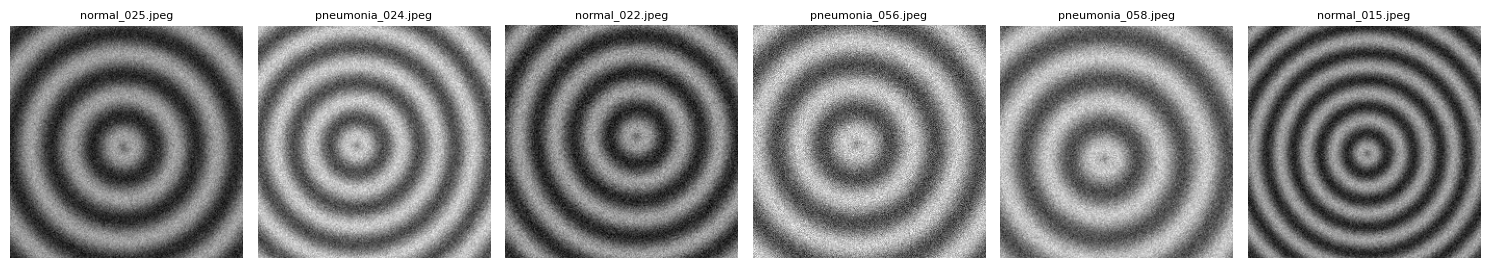

In [22]:
# C4: Resize, standardize channels, normalize pixel intensities
TARGET_SIZE = (224, 224)

def preprocess_image(path, size=TARGET_SIZE):
    with Image.open(path) as im:
        im = im.convert('L').resize(size)          # consistent single channel + consistent size
        arr = np.asarray(im, dtype=np.float32) / 255.0  # normalize to [0, 1]
    return arr

sample_paths = clean_index['path'].sample(min(6, len(clean_index)), random_state=1).tolist()
processed_tensors = [preprocess_image(p) for p in sample_paths]

print(f'Each processed image tensor shape: {processed_tensors[0].shape}')
print(f'Pixel value range after normalization: [{processed_tensors[0].min():.3f}, {processed_tensors[0].max():.3f}]')

fig, axes = plt.subplots(1, len(processed_tensors), figsize=(15, 3))
for ax, arr, p in zip(axes, processed_tensors, sample_paths):
    ax.imshow(arr, cmap='gray', vmin=0, vmax=1)
    ax.set_title(os.path.basename(p), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## C5 — Data Augmentation
**What:** Apply X-ray-appropriate augmentations — small rotations, horizontal flips, brightness/contrast jitter — to counter the class imbalance seen in C1 and improve generalization.
**Why these specific augmentations and not others (e.g. no vertical flip, no heavy color jitter):** a chest X-ray has a consistent anatomical orientation — flipping it vertically or rotating it 90 degrees would produce an anatomically nonsensical image a radiologist would never see, which would teach a model the wrong thing. Small rotations (a few degrees) and horizontal flips mimic realistic positioning variation during acquisition, and brightness/contrast jitter mimics variation in exposure settings across different machines — all *plausible* real-world variation, unlike an upside-down lung.
**Why augmentation addresses class imbalance:** applying more augmented copies specifically to the minority class (`NORMAL`, per the counts from C1) increases its effective representation in training without collecting a single new real image.


Minority class in train split: NORMAL ({'PNEUMONIA': 90, 'NORMAL': 32})


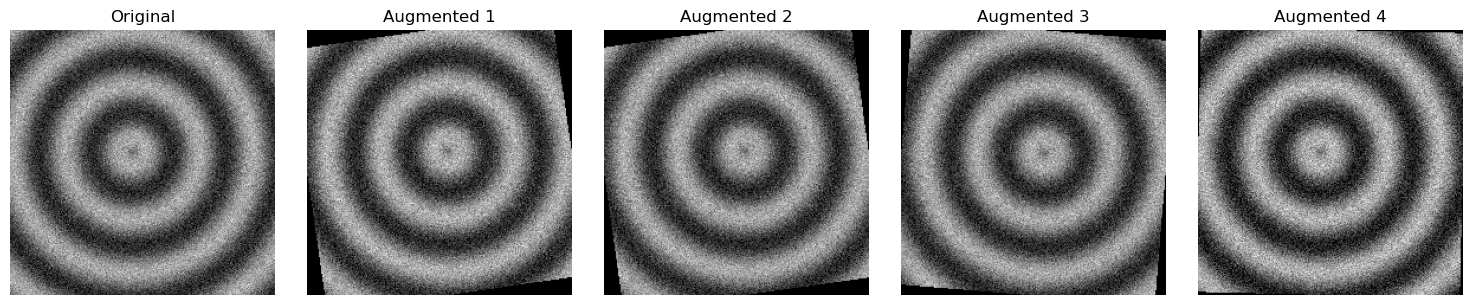

In [23]:
# C5: X-ray-appropriate augmentations, applied more heavily to the minority class
def augment_image(arr_uint8, rng):
    im = Image.fromarray(arr_uint8)
    angle = rng.uniform(-10, 10)                 # small rotation only - anatomically plausible
    im = im.rotate(angle, fillcolor=0)
    if rng.random() < 0.5:
        im = im.transpose(Image.FLIP_LEFT_RIGHT)  # horizontal flip only, never vertical
    im = ImageEnhance.Brightness(im).enhance(rng.uniform(0.85, 1.15))
    im = ImageEnhance.Contrast(im).enhance(rng.uniform(0.85, 1.15))
    return np.asarray(im)

class_counts = image_index.loc[image_index['split'] == 'train', 'class'].value_counts()
minority_class = class_counts.idxmin()
print(f'Minority class in train split: {minority_class} ({class_counts.to_dict()})')

rng = np.random.default_rng(3)
minority_paths = image_index.loc[(image_index['split'] == 'train') &
                                  (image_index['class'] == minority_class), 'path']
sample_path = minority_paths.sample(1, random_state=1).iloc[0]
with Image.open(sample_path) as im:
    orig_arr = np.asarray(im.convert('L'))

augmented_versions = [augment_image(orig_arr, rng) for _ in range(4)]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(orig_arr, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for i, aug in enumerate(augmented_versions):
    axes[i + 1].imshow(aug, cmap='gray'); axes[i + 1].set_title(f'Augmented {i+1}'); axes[i + 1].axis('off')
plt.tight_layout()
plt.show()


## C6 — Exploratory Data Analysis
**What:** Visualize sample images per class and quantify class imbalance.
**Why quantify imbalance numerically in addition to the bar chart:** a ratio (e.g. '3:1') is what actually determines the augmentation/resampling strategy (how many synthetic copies of the minority class are needed) — a chart alone tells you imbalance exists but not by how much.


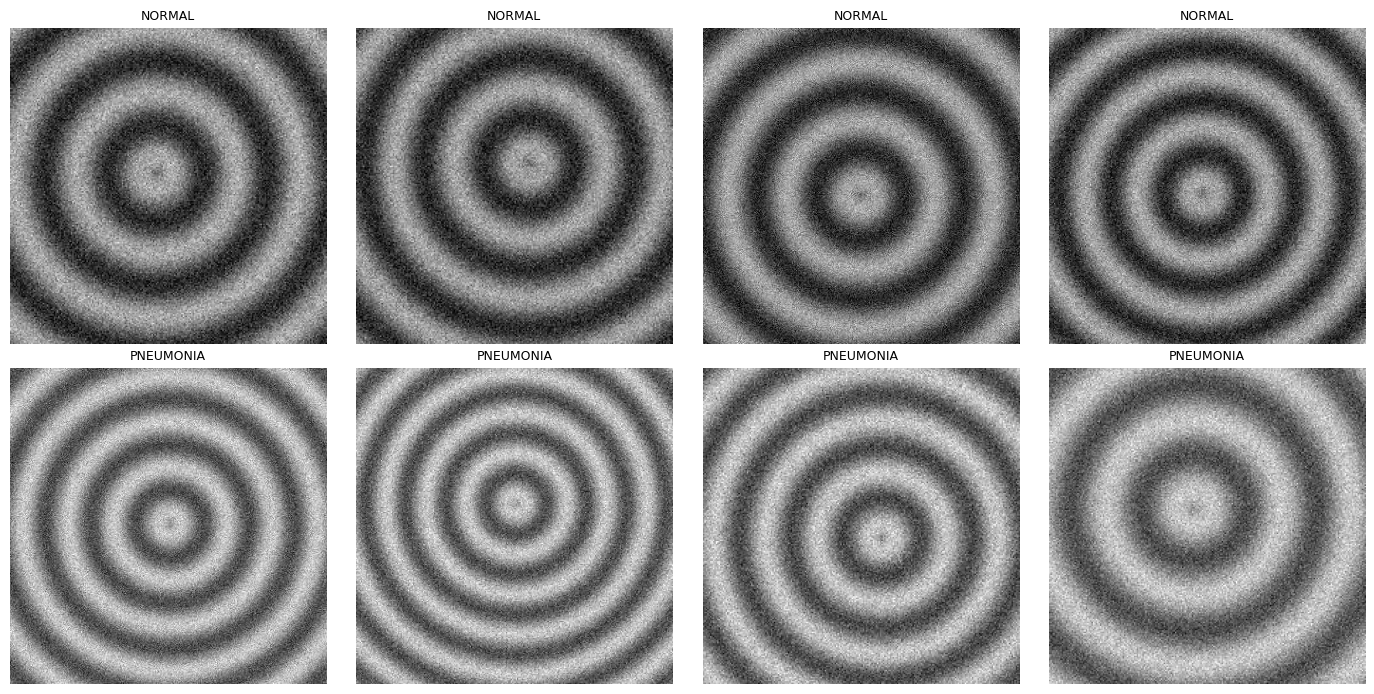

Train split class counts: {'PNEUMONIA': 90, 'NORMAL': 32}
Class imbalance ratio (majority:minority): 2.81 : 1


In [24]:
# C6: Sample images per class + quantified class imbalance
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    sample_files = image_index.loc[(image_index['split'] == 'train') &
                                    (image_index['class'] == cls), 'path'].sample(4, random_state=1)
    for col, fp in enumerate(sample_files):
        try:
            with Image.open(fp) as im:
                axes[row, col].imshow(im.convert('L'), cmap='gray')
        except Exception:
            axes[row, col].text(0.5, 0.5, 'unreadable', ha='center')
        axes[row, col].set_title(cls, fontsize=9)
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

train_counts = image_index.loc[image_index['split'] == 'train', 'class'].value_counts()
imbalance_ratio = train_counts.max() / train_counts.min()
print(f'Train split class counts: {train_counts.to_dict()}')
print(f'Class imbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1')


# Module 4 — Physiological Signal Processing: MIT-BIH Arrhythmia Database (ECG)
---


In [25]:
!pip install -q wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch

np.random.seed(42)


## 4.1 — Data Acquisition
**What:** Load a record using `wfdb`, inspect the raw signal, sampling rate, and annotation file.
**Why `wfdb` specifically:** as in Lab 1, MIT-BIH stores each record as a `.dat`/`.hea`/`.atr` triplet (raw samples / header / annotations) — `wfdb` is the official PhysioNet library that parses this triplet correctly, including the sampling rate declared in the header, which every later filtering step depends on.


In [26]:
import wfdb

RECORD, PN_DIR = '100', 'mitdb'

def load_ecg_record(record=RECORD, pn_dir=PN_DIR, sampfrom=0, sampto=7200):
    """Downloads one MIT-BIH record via wfdb; falls back to a synthetic ECG-like
    signal (with injected artifacts for the cleaning step below) if offline."""
    try:
        rec = wfdb.rdrecord(record, pn_dir=pn_dir, sampfrom=sampfrom, sampto=sampto)
        ann = wfdb.rdann(record, 'atr', pn_dir=pn_dir, sampfrom=sampfrom, sampto=sampto)
        print(f'Loaded real MIT-BIH record {record}: fs={rec.fs} Hz, {rec.p_signal.shape[0]} samples.')
        return rec.p_signal[:, 0], ann, rec.fs, 'real'
    except Exception as e:
        print(f'[Fallback] Could not reach PhysioNet ({e}). Generating a synthetic ECG-like signal instead.')
        fs = 360
        t = np.arange(sampfrom, sampto) / fs
        sig = 0.6 * np.sin(2 * np.pi * 1.2 * t) ** 5
        sig += 0.15 * np.sin(2 * np.pi * 0.3 * t)      # baseline wander
        sig += 0.05 * np.sin(2 * np.pi * 50 * t)        # powerline interference (50 Hz)
        sig += np.random.normal(0, 0.01, size=sig.shape)  # sensor noise
        # inject a flatline segment and a clipped segment to exercise the D2 checks
        sig[1000:1200] = 0.0
        sig[3000:3050] = np.clip(sig[3000:3050] * 5, -1, 1)
        peak_locs = np.arange(30, len(sig) - 30, int(fs * 0.83))
        class DummyAnn: pass
        ann = DummyAnn(); ann.sample = peak_locs; ann.symbol = ['N'] * len(peak_locs)
        return sig, ann, fs, 'synthetic'

ecg_raw, ecg_ann, fs, ecg_source = load_ecg_record()
print(f'Signal length: {len(ecg_raw)} samples | Sampling rate: {fs} Hz | Duration: {len(ecg_raw)/fs:.1f} s')


Loaded real MIT-BIH record 100: fs=360 Hz, 7200 samples.
Signal length: 7200 samples | Sampling rate: 360 Hz | Duration: 20.0 s


## 4.2 — Signal Inspection & Cleaning
**What:** Check for flatlines (a stuck sensor reading the same value for an extended stretch), clipped values (signal saturating at the amplifier's min/max), and missing samples (NaNs) in the raw signal.
**Why these three checks specifically, before any filtering:** each indicates a different *hardware* failure mode rather than a filterable noise type — a flatline usually means a lead came loose, clipping means the amplifier gain was set too high for that patient, and NaNs mean a data-transmission gap. None of these can be fixed by a bandpass/notch filter (D3); they need to be detected and either excluded or flagged before any frequency-domain processing is trusted.


In [27]:
# 4.2: Flatline, clipping, and missing-sample checks
def detect_flatlines(sig, window=50, tol=1e-6):
    flat_mask = np.zeros(len(sig), dtype=bool)
    for i in range(0, len(sig) - window, window):
        seg = sig[i:i + window]
        if seg.std() < tol:
            flat_mask[i:i + window] = True
    return flat_mask

def detect_clipping(sig, pct=0.995):
    hi, lo = np.quantile(sig, pct), np.quantile(sig, 1 - pct)
    return (sig >= hi) | (sig <= lo)

n_missing = np.isnan(ecg_raw).sum()
flat_mask = detect_flatlines(ecg_raw)
clip_mask = detect_clipping(ecg_raw)

print(f'Missing (NaN) samples: {n_missing}')
print(f'Flatline samples flagged: {flat_mask.sum()} ({flat_mask.sum()/len(ecg_raw):.2%} of signal)')
print(f'Clipped samples flagged: {clip_mask.sum()} ({clip_mask.sum()/len(ecg_raw):.2%} of signal)')

if n_missing > 0:
    ecg_raw = np.nan_to_num(ecg_raw, nan=np.nanmedian(ecg_raw))
    print('Missing samples filled with the signal median.')


Missing (NaN) samples: 0
Flatline samples flagged: 0 (0.00% of signal)
Clipped samples flagged: 73 (1.01% of signal)


## 4.3 — Noise Removal / Filtering
**What:** Apply a Butterworth **bandpass filter** (roughly 0.5-40 Hz) to remove baseline wander (very low frequency drift from breathing/movement) and high-frequency muscle noise, plus a **notch filter** at 50/60 Hz to remove powerline interference.
**Why bandpass *and* notch, not just one:** they target different noise sources at different frequencies — baseline wander sits below the passband entirely (near 0 Hz) while powerline hum is a narrow, sharp spike right in the middle of the passband; a wide bandpass alone wouldn't remove that spike, which is why a dedicated narrow notch filter is layered on top specifically at the mains frequency.
**Why `filtfilt` instead of a single-pass filter:** `filtfilt` applies the filter forward and backward, canceling out the phase shift a normal digital filter would introduce — phase distortion would shift the apparent timing of the R-peaks, which would corrupt the RR-interval timing computed in D5.


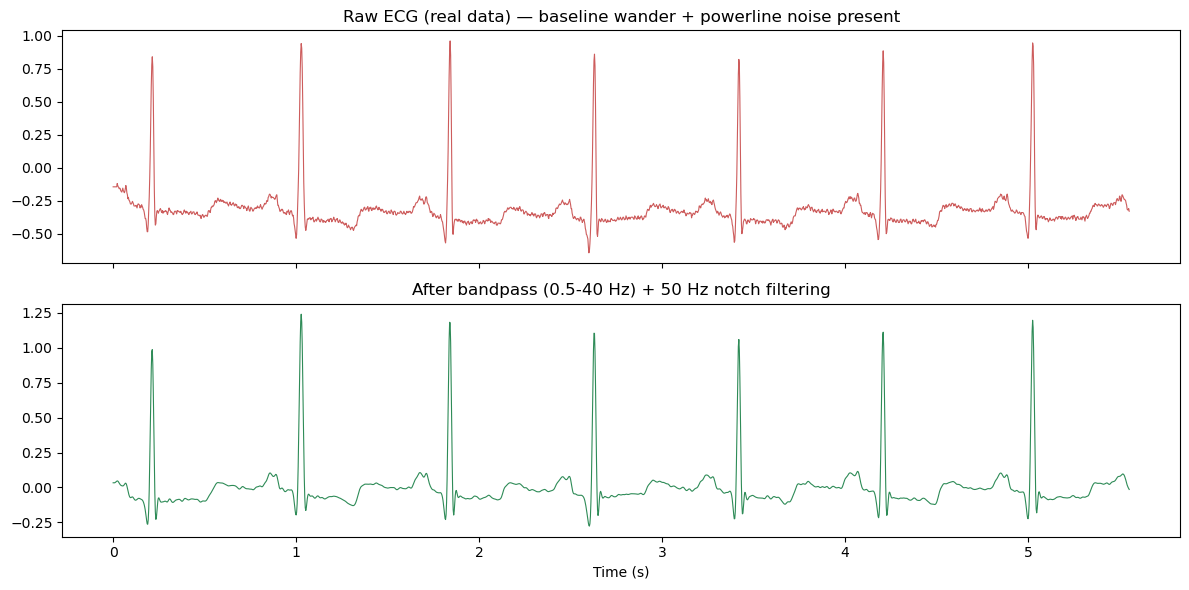

In [28]:
# 4.3: Bandpass + notch filtering
def bandpass_filter(sig, fs, low=0.5, high=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

def notch_filter(sig, fs, freq=50.0, quality=30.0):
    b, a = iirnotch(freq / (fs / 2), quality)
    return filtfilt(b, a, sig)

ecg_bandpassed = bandpass_filter(ecg_raw, fs)
ecg_filtered = notch_filter(ecg_bandpassed, fs, freq=50.0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
t = np.arange(len(ecg_raw)) / fs
window = slice(0, min(2000, len(ecg_raw)))
axes[0].plot(t[window], ecg_raw[window], linewidth=0.8, color='indianred')
axes[0].set_title(f'Raw ECG ({ecg_source} data) — baseline wander + powerline noise present')
axes[1].plot(t[window], ecg_filtered[window], linewidth=0.8, color='seagreen')
axes[1].set_title('After bandpass (0.5-40 Hz) + 50 Hz notch filtering')
axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


## D4 — Segmentation
**What:** Detect R-peaks in the cleaned signal and segment the continuous recording into individual heartbeat windows centered on each peak.
**Why detect peaks on the *filtered* signal, not the raw one:** baseline wander in the raw signal would shift the effective threshold up and down across the recording, causing a fixed-height peak detector to miss beats during a drift or false-fire on noise — filtering first is what makes simple peak detection reliable.
**Why a fixed-width window around each peak:** giving every beat the same window length (e.g. 0.6s total) is what makes the resulting beats directly comparable/stackable as a matrix of equal-length rows for any downstream model, instead of variable-length segments that would need padding.


Detected 25 R-peaks in 20.0s of signal.
Segmented 23 complete beat windows, each of shape (216,)


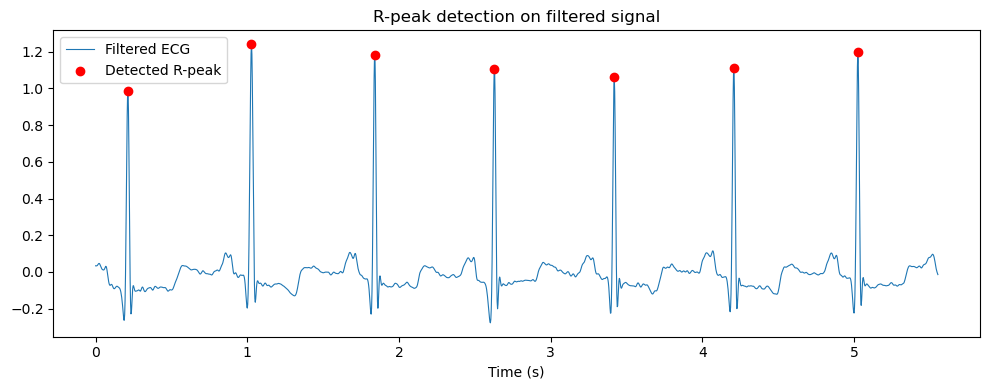

In [29]:
# D4: R-peak detection and beat segmentation
min_distance = int(fs * 0.4)  # refractory period: no two real beats closer than ~0.4s (150 bpm cap)
peaks, _ = find_peaks(ecg_filtered, distance=min_distance,
                       height=np.percentile(ecg_filtered, 90))
print(f'Detected {len(peaks)} R-peaks in {len(ecg_filtered)/fs:.1f}s of signal.')

half_window = int(fs * 0.3)  # +/- 0.3s -> 0.6s beat window
beats = []
for p in peaks:
    if p - half_window >= 0 and p + half_window < len(ecg_filtered):
        beats.append(ecg_filtered[p - half_window: p + half_window])
beats = np.array(beats)
print(f'Segmented {len(beats)} complete beat windows, each of shape {beats.shape[1:]}')

plt.figure(figsize=(10, 4))
t_full = np.arange(len(ecg_filtered)) / fs
plt.plot(t_full[window], ecg_filtered[window], linewidth=0.8, label='Filtered ECG')
peak_in_window = peaks[peaks < window.stop]
plt.scatter(peak_in_window / fs, ecg_filtered[peak_in_window], color='red', zorder=3, label='Detected R-peak')
plt.title('R-peak detection on filtered signal')
plt.xlabel('Time (s)'); plt.legend()
plt.tight_layout()
plt.show()


## D5 — Feature Extraction
**What:** Compute time-domain features (RR-interval mean/std, RMSSD — a standard HRV metric) and a frequency-domain feature (spectral power in the LF/HF heart-rate-variability bands via Welch's method).
**Why RMSSD specifically among time-domain options:** it's the standard clinical HRV metric that specifically captures beat-to-beat variability (as opposed to SDNN, which is more sensitive to slow trends over the whole recording) — RMSSD is the metric most directly computed from consecutive RR-interval differences for HRV evaluation.
**Why frequency-domain features in addition to time-domain:** LF (low-frequency, ~0.04-0.15 Hz) and HF (high-frequency, ~0.15-0.4 Hz) spectral power reflect sympathetic vs. parasympathetic nervous system activity respectively — information that time-domain statistics alone (mean/std of RR intervals) cannot separate out, since two very different LF/HF balances can share the same overall RR standard deviation.


In [30]:
# D5: Time-domain (RR interval stats, RMSSD) and frequency-domain (LF/HF power) features
rr_intervals_sec = np.diff(peaks) / fs

rr_mean = rr_intervals_sec.mean()
rr_std = rr_intervals_sec.std()
rmssd = np.sqrt(np.mean(np.diff(rr_intervals_sec) ** 2))
mean_hr = 60 / rr_mean

print('Time-domain features:')
print(f'  Mean RR interval: {rr_mean:.3f} s')
print(f'  SDNN (std of RR):  {rr_std*1000:.1f} ms')
print(f'  RMSSD:             {rmssd*1000:.1f} ms')
print(f'  Mean heart rate:   {mean_hr:.1f} bpm')

# Frequency-domain: interpolate the RR-interval series onto a uniform time grid, then Welch's method
rr_times = np.cumsum(rr_intervals_sec)
fs_interp = 4.0  # standard HRV resampling rate
t_uniform = np.arange(rr_times[0], rr_times[-1], 1 / fs_interp)
rr_uniform = np.interp(t_uniform, rr_times, rr_intervals_sec)

freqs, psd = welch(rr_uniform, fs=fs_interp, nperseg=min(256, len(rr_uniform)))
lf_band = (freqs >= 0.04) & (freqs < 0.15)
hf_band = (freqs >= 0.15) & (freqs < 0.40)

def band_power(freqs_band, psd_band):
    """Manual trapezoidal integration (avoids relying on a specific numpy version's trapz/trapezoid name)."""
    if len(freqs_band) < 2:
        return 0.0
    return float(np.sum(0.5 * (psd_band[:-1] + psd_band[1:]) * np.diff(freqs_band)))

lf_power = band_power(freqs[lf_band], psd[lf_band])
hf_power = band_power(freqs[hf_band], psd[hf_band])

print('\nFrequency-domain features:')
print(f'  LF power (0.04-0.15 Hz): {lf_power:.6f}')
print(f'  HF power (0.15-0.40 Hz): {hf_power:.6f}')
print(f'  LF/HF ratio: {(lf_power / hf_power if hf_power > 0 else float("nan")):.3f}')


Time-domain features:
  Mean RR interval: 0.814 s
  SDNN (std of RR):  55.0 ms
  RMSSD:             90.2 ms
  Mean heart rate:   73.8 bpm

Frequency-domain features:
  LF power (0.04-0.15 Hz): 0.000021
  HF power (0.15-0.40 Hz): 0.001048
  LF/HF ratio: 0.020


## D6 — Normalization
**What:** Normalize each individual beat window to a consistent amplitude scale, and normalize the extracted feature vector (RR stats, RMSSD, LF/HF power) to a consistent scale as well.
**Why normalize each beat *individually* rather than the whole signal at once:** absolute ECG amplitude varies between patients (and even across a single recording, due to electrode contact quality) — per-beat min-max scaling makes beat *shapes* comparable across patients and time, which matters if these beats were later fed into a shape-based classifier (e.g. arrhythmia detection), whereas a single global scaling would still leave amplitude differences baked into each beat.
**Why the feature vector needs its own separate normalization:** RR interval (~seconds), RMSSD (~milliseconds), and LF/HF power (very small raw magnitudes, as seen above) live on completely different numeric scales — exactly the same problem as tabular features, solved the same way, with standardization so no single feature dominates a downstream model purely due to its units.


Normalized beat value range: [0.000, 1.000]


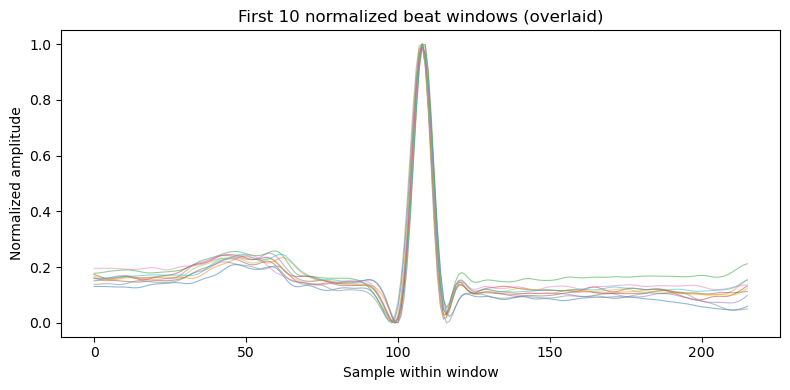

,raw,z_normalized
rr_mean,0.813542,-0.424517
rr_std,0.055011,-0.452185
rmssd,0.090230,-0.450900
mean_hr,73.751601,2.235947
lf_power,0.000021,-0.454191
hf_power,0.001048,-0.454153


In [31]:
# D6: Normalize beat windows (per-beat min-max) and the extracted feature vector (z-score)
def normalize_beat(beat):
    b_min, b_max = beat.min(), beat.max()
    return (beat - b_min) / (b_max - b_min) if b_max > b_min else beat - b_min

normalized_beats = np.array([normalize_beat(b) for b in beats])
print(f'Normalized beat value range: [{normalized_beats.min():.3f}, {normalized_beats.max():.3f}]')

plt.figure(figsize=(8, 4))
for b in normalized_beats[:10]:
    plt.plot(b, alpha=0.5, linewidth=0.8)
plt.title('First 10 normalized beat windows (overlaid)')
plt.xlabel('Sample within window'); plt.ylabel('Normalized amplitude')
plt.tight_layout()
plt.show()

feature_vector = np.array([rr_mean, rr_std, rmssd, mean_hr, lf_power, hf_power])
feature_names_d = ['rr_mean', 'rr_std', 'rmssd', 'mean_hr', 'lf_power', 'hf_power']
z_features = (feature_vector - feature_vector.mean()) / feature_vector.std()

import pandas as pd
pd.DataFrame({'raw': feature_vector, 'z_normalized': z_features}, index=feature_names_d)
